# Лабораторная работа №4
  
## Тема: Ассоциативный анализ
  
## Цель работы: Ознакомиться с методами ассоциативного анализа из библиотеки MLxtend.

**Студент:** Магомедов Имран Борисович  
**Группа:** ПИЖ-Б-О-22-1  
**Курс/Семестр:** 4/8  

## Методика и порядок выполнения работы

In [12]:
import warnings

warnings.filterwarnings("ignore")

In [13]:
!pip install mlxtend

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, fpmax, association_rules
import networkx as nx

### Загрузка данных

2. Загрузка данных

In [38]:
all_data = pd.read_csv('/content/drive/MyDrive/NCFU/ОиАБД/Отчеты/Лабораторная работа №4/data/groceries - groceries.csv')
print("Исходные данные:")
print(all_data.head())
print(f"Размер данных: {all_data.shape}")

Исходные данные:
   Item(s)            Item 1               Item 2          Item 3  \
0        4      citrus fruit  semi-finished bread       margarine   
1        3    tropical fruit               yogurt          coffee   
2        1        whole milk                  NaN             NaN   
3        4         pip fruit               yogurt    cream cheese   
4        4  other vegetables           whole milk  condensed milk   

                     Item 4 Item 5 Item 6 Item 7 Item 8 Item 9  ... Item 23  \
0               ready soups    NaN    NaN    NaN    NaN    NaN  ...     NaN   
1                       NaN    NaN    NaN    NaN    NaN    NaN  ...     NaN   
2                       NaN    NaN    NaN    NaN    NaN    NaN  ...     NaN   
3              meat spreads    NaN    NaN    NaN    NaN    NaN  ...     NaN   
4  long life bakery product    NaN    NaN    NaN    NaN    NaN  ...     NaN   

  Item 24 Item 25 Item 26 Item 27 Item 28 Item 29 Item 30 Item 31 Item 32  
0     NaN     NaN

3. Удаление NaN значений

In [39]:
np_data = all_data.to_numpy()
np_data = [[elem for elem in row[1:] if isinstance(elem, str)] for row in np_data]
print(f"Количество транзакций после очистки: {len(np_data)}")

Количество транзакций после очистки: 9835


4. Получение списка всех уникальных товаров

In [40]:
unique_items = set()
for row in np_data:
    for elem in row:
        unique_items.add(elem)

5. Вывод списка товаров и их количества

In [41]:
print(f"=== Уникальные товары ===")
print(f"Количество уникальных товаров: {len(unique_items)}")
print("Первые 20 товаров:")
print(list(sorted(unique_items))[:20])

=== Уникальные товары ===
Количество уникальных товаров: 169
Первые 20 товаров:
['Instant food products', 'UHT-milk', 'abrasive cleaner', 'artif. sweetener', 'baby cosmetics', 'baby food', 'bags', 'baking powder', 'bathroom cleaner', 'beef', 'berries', 'beverages', 'bottled beer', 'bottled water', 'brandy', 'brown bread', 'butter', 'butter milk', 'cake bar', 'candles']


### FPGrowth и FPMax

1. Преобразование данных

In [42]:
te = TransactionEncoder()
te_ary = te.fit(np_data).transform(np_data)
data = pd.DataFrame(te_ary, columns=te.columns_)
print(f"Размер матрицы транзакций: {data.shape}")

Размер матрицы транзакций: (9835, 169)


2. FPGrowth при поддержке 0.03

In [43]:
print("=== FPGrowth (min_support=0.03) ===")
result_fp = fpgrowth(data, min_support=0.03, use_colnames=True)
result_fp['length'] = result_fp['itemsets'].apply(lambda x: len(x))
print(result_fp)
print(f"\nВсего наборов: {len(result_fp)}")

=== FPGrowth (min_support=0.03) ===
     support                             itemsets  length
0   0.082766                       (citrus fruit)       1
1   0.058566                          (margarine)       1
2   0.139502                             (yogurt)       1
3   0.104931                     (tropical fruit)       1
4   0.058058                             (coffee)       1
..       ...                                  ...     ...
58  0.033249                 (whole milk, pastry)       2
59  0.047382  (other vegetables, root vegetables)       2
60  0.048907        (whole milk, root vegetables)       2
61  0.030605                (rolls/buns, sausage)       2
62  0.032232     (whole milk, whipped/sour cream)       2

[63 rows x 3 columns]

Всего наборов: 63


3. Анализ уровней поддержки для наборов разного размера

In [44]:
print("=== Анализ поддержки для наборов разного размера ===")
for length in [1, 2, 3, 4]:
    subset = result_fp[result_fp['length'] == length]
    if len(subset) > 0:
        print(f"Наборы размера {length}:")
        print(f"  Минимальная поддержка: {subset['support'].min():.4f}")
        print(f"  Максимальная поддержка: {subset['support'].max():.4f}")
        print(f"  Количество: {len(subset)}")

=== Анализ поддержки для наборов разного размера ===
Наборы размера 1:
  Минимальная поддержка: 0.0304
  Максимальная поддержка: 0.2555
  Количество: 44
Наборы размера 2:
  Минимальная поддержка: 0.0301
  Максимальная поддержка: 0.0748
  Количество: 19


4. FPMax

In [45]:
print("=== FPMax (min_support=0.03) ===")
result_fpmax = fpmax(data, min_support=0.03, use_colnames=True)
result_fpmax['length'] = result_fpmax['itemsets'].apply(lambda x: len(x))
print(result_fpmax)
print(f"\nВсего наборов: {len(result_fpmax)}")

=== FPMax (min_support=0.03) ===
     support                             itemsets  length
0   0.030402                (specialty chocolate)       1
1   0.031012                             (onions)       1
2   0.032944                   (hygiene articles)       1
3   0.033249                            (berries)       1
4   0.033249                     (hamburger meat)       1
5   0.033452                           (UHT-milk)       1
6   0.033859                              (sugar)       1
7   0.037112                            (dessert)       1
8   0.037417           (long life bakery product)       1
9   0.037824                        (salty snack)       1
10  0.038434                            (waffles)       1
11  0.039654                       (cream cheese)       1
12  0.042095                        (white bread)       1
13  0.042908                            (chicken)       1
14  0.048094                  (frozen vegetables)       1
15  0.049619                          (

5. Сравнение результатов

In [46]:
print("=== Сравнение FPGrowth и FPMax ===")
print(f"FPGrowth: {len(result_fp)} частых наборов")
print(f"FPMax: {len(result_fpmax)} частых наборов")

=== Сравнение FPGrowth и FPMax ===
FPGrowth: 63 частых наборов
FPMax: 50 частых наборов


Разница: FPMax находит только максимальные частые наборы (не включая их подмножества), а FPGrowth находит все частые наборы. FPMax возвращает меньше результатов, но они более информативны, так как представляют самые большие комбинации.

6. Гистограмма 10 самых встречаемых товаров

=== Топ-10 самых частых товаров ===


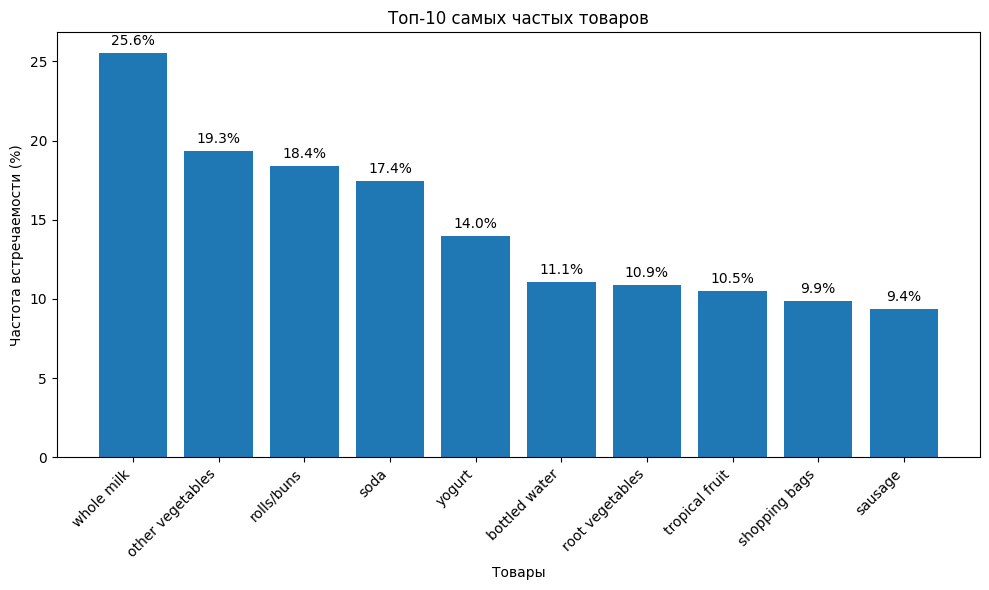


Корреляция с результатами FPGrowth:
              itemsets   support
5         (whole milk)  0.255516
8   (other vegetables)  0.193493
11        (rolls/buns)  0.183935
19              (soda)  0.174377
2             (yogurt)  0.139502
14     (bottled water)  0.110524
26   (root vegetables)  0.108998
3     (tropical fruit)  0.104931
31     (shopping bags)  0.098526
30           (sausage)  0.093950


In [47]:
print("=== Топ-10 самых частых товаров ===")
item_frequencies = data.sum().sort_values(ascending=False)
top10 = item_frequencies.head(10)

plt.figure(figsize=(10, 6))
plt.bar(range(len(top10)), top10.values / len(data) * 100)
plt.xticks(range(len(top10)), top10.index, rotation=45, ha='right')
plt.xlabel('Товары')
plt.ylabel('Частота встречаемости (%)')
plt.title('Топ-10 самых частых товаров')
for i, v in enumerate(top10.values / len(data) * 100):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

print("\nКорреляция с результатами FPGrowth:")
fp_top = result_fp[result_fp['length'] == 1].sort_values('support', ascending=False).head(10)
print(fp_top[['itemsets', 'support']])

7. Преобразование с ограниченным набором товаров

In [48]:
print("=== Создание датасета с ограниченным набором товаров ===")
items = ['whole milk', 'yogurt', 'soda', 'tropical fruit', 'shopping bags', 'sausage',
         'whipped/sour cream', 'rolls/buns', 'other vegetables', 'root vegetables',
         'pork', 'bottled water', 'pastry', 'citrus fruit', 'canned beer', 'bottled beer']

np_data_limited = all_data.to_numpy()
np_data_limited = [[elem for elem in row[1:] if isinstance(elem, str) and elem in items]
                   for row in np_data_limited]
np_data_limited = [row for row in np_data_limited if len(row) > 0]

=== Создание датасета с ограниченным набором товаров ===


8. Анализ FPGrowth и FPMax для нового набора

In [50]:
te_limited = TransactionEncoder()
te_ary_limited = te_limited.fit(np_data_limited).transform(np_data_limited)
data_limited = pd.DataFrame(te_ary_limited, columns=te_limited.columns_)

print("=== FPGrowth (ограниченный набор) ===")
result_fp_limited = fpgrowth(data_limited, min_support=0.03, use_colnames=True)
result_fp_limited['length'] = result_fp_limited['itemsets'].apply(lambda x: len(x))
print(f"Количество наборов: {len(result_fp_limited)}")
print(result_fp_limited)

print("\n=== FPMax (ограниченный набор) ===")
result_fpmax_limited = fpmax(data_limited, min_support=0.03, use_colnames=True)
result_fpmax_limited['length'] = result_fpmax_limited['itemsets'].apply(lambda x: len(x))
print(f"Количество наборов: {len(result_fpmax_limited)}")
print(result_fpmax_limited)

=== FPGrowth (ограниченный набор) ===
Количество наборов: 43
     support                                itemsets  length
0   0.100693                          (citrus fruit)       1
1   0.169718                                (yogurt)       1
2   0.127660                        (tropical fruit)       1
3   0.310861                            (whole milk)       1
4   0.235403                      (other vegetables)       1
5   0.223775                            (rolls/buns)       1
6   0.097971                          (bottled beer)       1
7   0.134463                         (bottled water)       1
8   0.212147                                  (soda)       1
9   0.108238                                (pastry)       1
10  0.132608                       (root vegetables)       1
11  0.094508                           (canned beer)       1
12  0.114300                               (sausage)       1
13  0.119866                         (shopping bags)       1
14  0.087209            

Изменения: количество наборов значительно уменьшилось, так как отобраны только 16 товаров

9. График изменения количества правил от поддержки

=== Зависимость количества наборов от поддержки ===


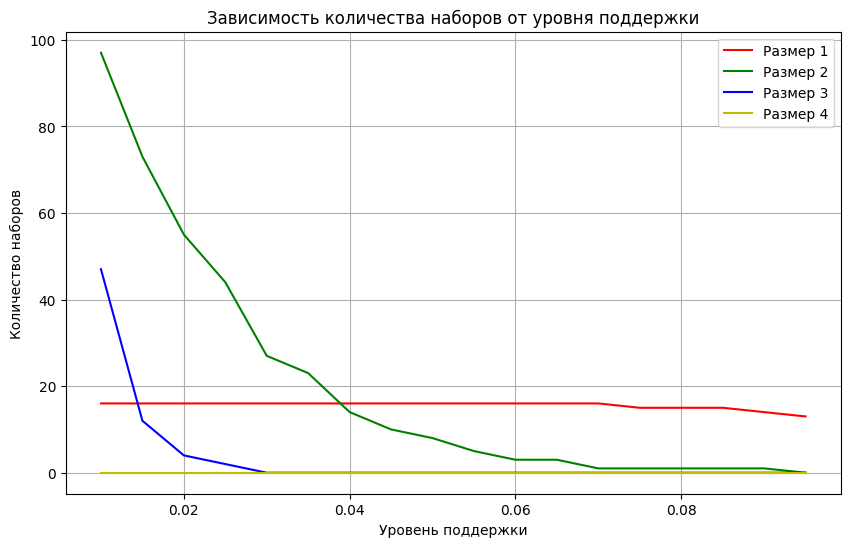

In [51]:
print("=== Зависимость количества наборов от поддержки ===")
support_levels = np.arange(0.01, 0.1, 0.005)
counts_len1 = []
counts_len2 = []
counts_len3 = []
counts_len4 = []

for support in support_levels:
    res = fpgrowth(data_limited, min_support=support, use_colnames=True)
    res['length'] = res['itemsets'].apply(lambda x: len(x))
    counts_len1.append(len(res[res['length'] == 1]))
    counts_len2.append(len(res[res['length'] == 2]))
    counts_len3.append(len(res[res['length'] == 3]))
    counts_len4.append(len(res[res['length'] == 4]))

plt.figure(figsize=(10, 6))
plt.plot(support_levels, counts_len1, 'r-', label='Размер 1')
plt.plot(support_levels, counts_len2, 'g-', label='Размер 2')
plt.plot(support_levels, counts_len3, 'b-', label='Размер 3')
plt.plot(support_levels, counts_len4, 'y-', label='Размер 4')
plt.xlabel('Уровень поддержки')
plt.ylabel('Количество наборов')
plt.title('Зависимость количества наборов от уровня поддержки')
plt.legend()
plt.grid()
plt.show()

Выводы: с увеличением поддержки количество наборов уменьшается. Наборы большего размера исчезают быстрее при повышении порога поддержки.

### Ассоциативные правила

1. Формирование датасета с транзакциями размера 2 и более

In [52]:
print("=== Формирование датасета (транзакции >= 2 товара) ===")
np_data_rules = all_data.to_numpy()
np_data_rules = [[elem for elem in row[1:] if isinstance(elem, str) and elem in items]
                 for row in np_data_rules]
np_data_rules = [row for row in np_data_rules if len(row) > 1]
print(f"Количество транзакций: {len(np_data_rules)}")

te_rules = TransactionEncoder()
te_ary_rules = te_rules.fit(np_data_rules).transform(np_data_rules)
data_rules = pd.DataFrame(te_ary_rules, columns=te_rules.columns_)

=== Формирование датасета (транзакции >= 2 товара) ===
Количество транзакций: 4966


2. Получение частот наборов

In [29]:
result_rules = fpgrowth(data_rules, min_support=0.05, use_colnames=True)

 3. Ассоциативные правила

In [54]:
print("=== Ассоциативные правила (min_threshold=0.3) ===")
rules = association_rules(result_rules, metric='confidence', min_threshold=0.3)
print(rules)
print(f"\nВсего правил: {len(rules)}")

=== Ассоциативные правила (min_threshold=0.3) ===
             antecedents         consequents  antecedent support  \
0               (yogurt)        (whole milk)            0.241240   
1               (yogurt)  (other vegetables)            0.241240   
2       (tropical fruit)            (yogurt)            0.185864   
3       (tropical fruit)  (other vegetables)            0.185864   
4       (tropical fruit)        (whole milk)            0.185864   
5           (whole milk)  (other vegetables)            0.421869   
6     (other vegetables)        (whole milk)            0.335079   
7           (rolls/buns)        (whole milk)            0.296214   
8        (bottled water)        (whole milk)            0.185461   
9        (bottled water)              (soda)            0.185461   
10        (citrus fruit)        (whole milk)            0.146395   
11        (citrus fruit)  (other vegetables)            0.146395   
12     (root vegetables)  (other vegetables)            0.196335  

Описание колонок:
- antecedents: набор товаров-условий (если купили это)
- consequents: набор товаров-следствий (то купят и это)
- antecedent support: частота встречаемости antecedents
- consequent support: частота встречаемости consequents
- support: частота встречаемости правила (antecedents U consequents)
- confidence: условная вероятность P(consequents | antecedents)
- lift: насколько вероятнее купить consequents при наличии antecedents
- leverage: разница между наблюдаемой и ожидаемой частотой
- conviction: степень зависимости между antecedents и consequents
- zhangs_metric: метрика Чжана для оценки ассоциации

4. Метрика расчета

По умолчанию используется metric='confidence'

confidence = support(antecedents U consequents) / support(antecedents)

5. Построение правил для различных метрик

In [55]:
print("=== Ассоциативные правила для различных метрик ===")
metrics = ['confidence', 'lift', 'leverage', 'conviction']

for metric in metrics:
    try:
        rules_metric = association_rules(result_rules, metric=metric, min_threshold=0.5)
        print(f"\n{metric}: {len(rules_metric)} правил")
        if len(rules_metric) > 0:
            print(rules_metric[['antecedents', 'consequents', 'support', metric]].head(3))
    except:
        print(f"{metric}: не удалось сформировать правила")

=== Ассоциативные правила для различных метрик ===

confidence: 1 правил
            antecedents   consequents   support  confidence
0  (whipped/sour cream)  (whole milk)  0.063834    0.513776

lift: 52 правил
    antecedents   consequents   support      lift
0  (whole milk)      (yogurt)  0.110954  1.090228
1      (yogurt)  (whole milk)  0.110954  1.090228
2        (soda)      (yogurt)  0.054168  0.840294

leverage: 0 правил

conviction: 52 правил
    antecedents   consequents   support  conviction
0  (whole milk)      (yogurt)  0.110954    1.029535
1      (yogurt)  (whole milk)  0.110954    1.070481
2        (soda)      (yogurt)  0.054168    0.951677


Смысл метрик:
- confidence: надежность правила (от 0 до 1)
- lift: >1 означает положительную зависимость
- leverage: >0 означает, что правило лучше случайного
- conviction: >1 означает сильную зависимость

6. Статистика метрик

In [56]:
print("=== Статистика метрик ===")
for metric in ['support', 'confidence', 'lift', 'leverage', 'conviction']:
    if metric in rules.columns:
        print(f"{metric}:")
        print(f"  Среднее: {rules[metric].mean():.4f}")
        print(f"  Медиана: {rules[metric].median():.4f}")
        print(f"  СКО: {rules[metric].std():.4f}")

=== Статистика метрик ===
support:
  Среднее: 0.0806
  Медиана: 0.0670
  СКО: 0.0294
confidence:
  Среднее: 0.4015
  Медиана: 0.3865
  СКО: 0.0621
lift:
  Среднее: 1.1028
  Медиана: 1.0793
  СКО: 0.1578
leverage:
  Среднее: 0.0058
  Медиана: 0.0073
  СКО: 0.0098
conviction:
  Среднее: 1.0607
  Медиана: 1.0568
  СКО: 0.0989


7. Построение графа

=== Построение графа ассоциативных правил ===


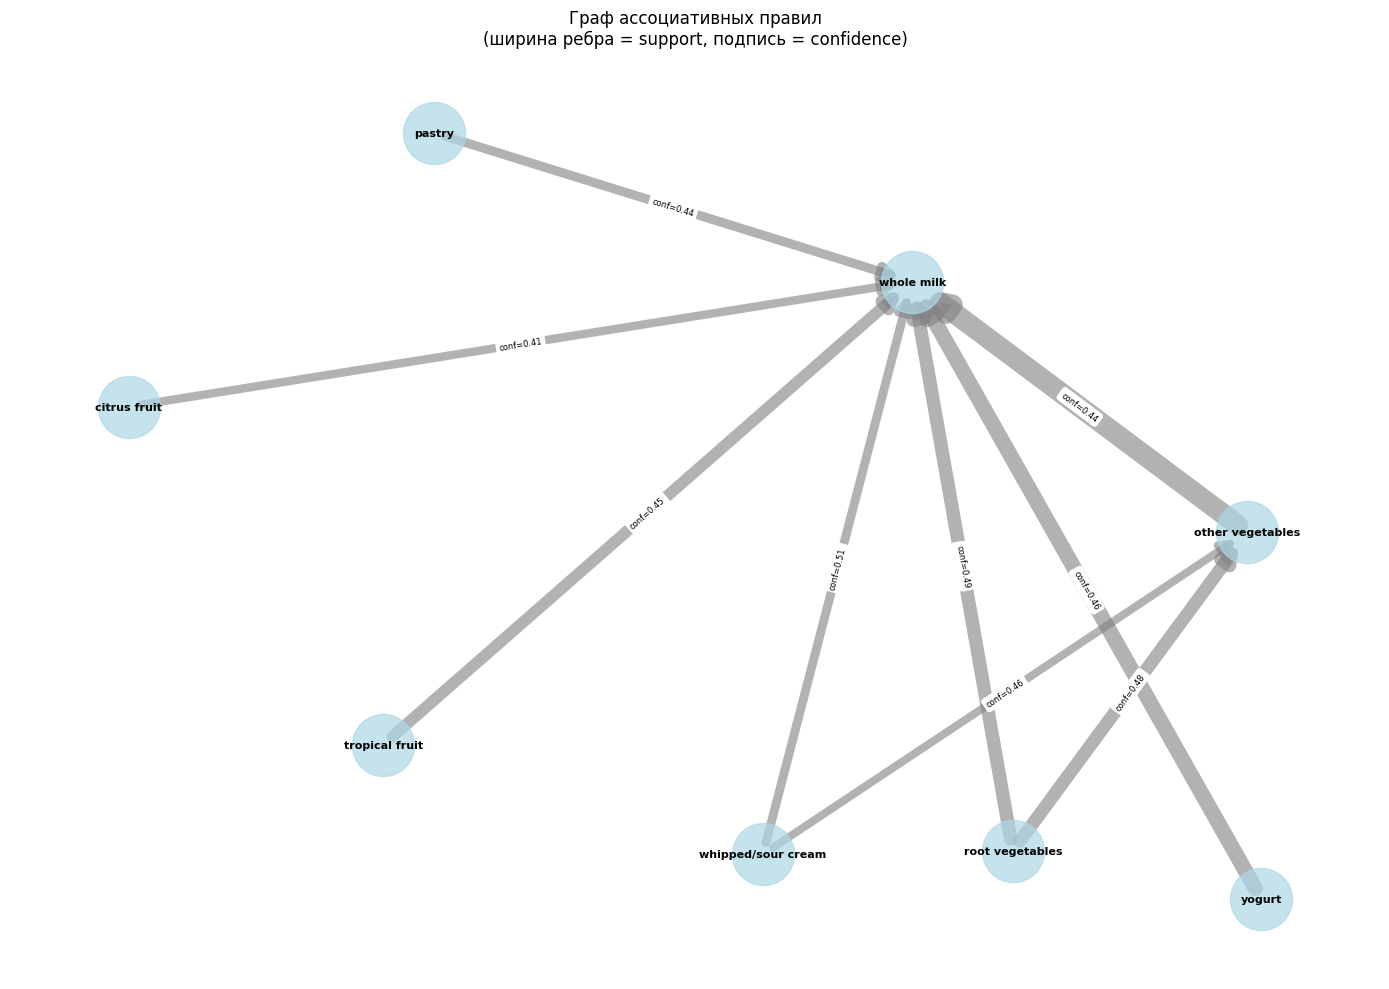

In [57]:
print("=== Построение графа ассоциативных правил ===")
rules_graph = association_rules(result_rules, metric='confidence', min_threshold=0.4)

G = nx.DiGraph()

# Добавление вершин и ребер
for _, rule in rules_graph.iterrows():
    ant = str(list(rule['antecedents'])[0]) if len(rule['antecedents']) == 1 else str(tuple(rule['antecedents']))
    cons = str(list(rule['consequents'])[0]) if len(rule['consequents']) == 1 else str(tuple(rule['consequents']))

    G.add_edge(ant, cons,
               weight=rule['support'] * 100,
               confidence=rule['confidence'])

# Отрисовка графа
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=2, iterations=50)

# Рисование узлов
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='lightblue', alpha=0.7)

# Рисование ребер с разной толщиной
edges = G.edges(data=True)
edge_widths = [edge[2]['weight'] for edge in edges]
nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color='gray', alpha=0.6, arrows=True, arrowsize=20)

# Рисование меток
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')

# Добавление подписей на ребра
edge_labels = {(u, v): f"conf={d['confidence']:.2f}" for u, v, d in edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)

plt.title('Граф ассоциативных правил\n(ширина ребра = support, подпись = confidence)')
plt.axis('off')
plt.tight_layout()
plt.show()

8. Анализ графа

Граф показывает связи между товарами:
- Узлы: товары или наборы товаров
- Направление: от antecedents к consequents
- Ширина ребра: уровень поддержки (чем шире, тем чаще правило встречается)
- Подпись: confidence (надежность правила)

In [58]:
print("Наиболее сильные связи:")
for u, v, d in sorted(edges, key=lambda x: x[2]['confidence'], reverse=True)[:5]:
    print(f"  {u} -> {v}: confidence={d['confidence']:.3f}, support={d['weight']:.2f}%")

Наиболее сильные связи:
  whipped/sour cream -> whole milk: confidence=0.514, support=6.38%
  root vegetables -> whole milk: confidence=0.493, support=9.69%
  root vegetables -> other vegetables: confidence=0.478, support=9.38%
  whipped/sour cream -> other vegetables: confidence=0.460, support=5.72%
  yogurt -> whole milk: confidence=0.460, support=11.10%


9. Предложение способов визуализации

1. Тепловая карта (heatmap) для матрицы lift между товарами
2. Сетевая диаграмма с кластеризацией товаров по группам
3. Диаграмма рассеяния support vs confidence с размером точек по lift
4. Параллельные координаты для визуализации многомерных правил
5. Дендрограмма для иерархической кластеризации товаров на основе co-occurrence
6. Sankey diagram для отображения потоков покупок

## Выводы

В ходе работы были изучены алгоритмы ассоциативного анализа FPGrowth и FPMax. FPGrowth находит все частые наборы, а FPMax — только максимальные. Построена гистограмма частоты товаров. Исследована зависимость количества наборов от поддержки. Сформированы ассоциативные правила, проанализированы метрики (confidence, lift, leverage, conviction). Построен ориентированный граф, где ширина ребра отображает support, а подпись — confidence. Предложены альтернативные способы визуализации правил.